In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


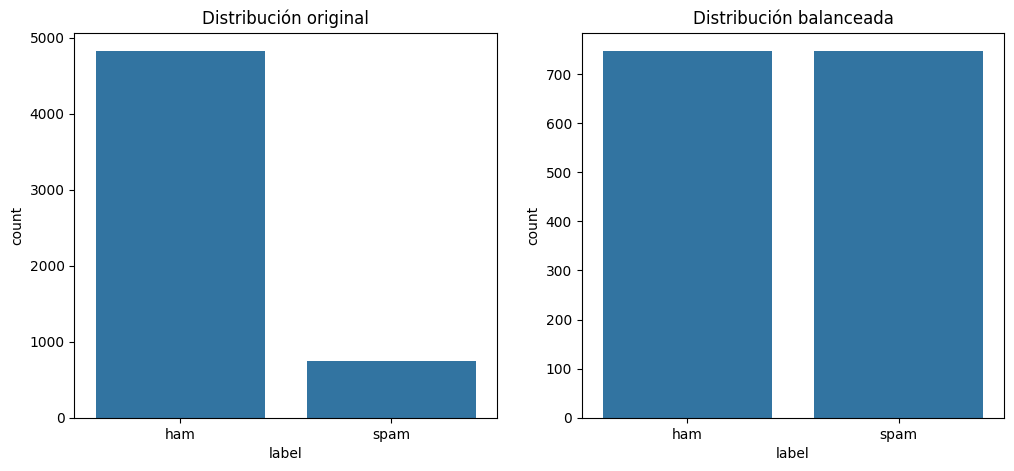

In [ ]:
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('spam.csv', encoding='latin1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Mapear etiquetas a numéricas
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Balancear dataset por submuestreo
majority = df[df['label'] == 'ham']
minority = df[df['label'] == 'spam']

majority_downsampled = resample(majority,
                               replace=False,
                               n_samples=len(minority),
                               random_state=42)

df_balanced = pd.concat([majority_downsampled, minority])

# Visualizar distribución
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x='label', data=df)
plt.title('Distribución original')
plt.subplot(1,2,2)
sns.countplot(x='label', data=df_balanced)
plt.title('Distribución balanceada')
plt.show()



In [20]:
# Mostrar números exactos
print("=== Distribución ORIGINAL ===")
print(df['label'].value_counts())
print(f"Total: {len(df)} casos\n")

print("=== Distribución BALANCEADA ===")
print(df_balanced['label'].value_counts())
print(f"Total: {len(df_balanced)} casos")

=== Distribución ORIGINAL ===
label
ham     4825
spam     747
Name: count, dtype: int64
Total: 5572 casos

=== Distribución BALANCEADA ===
label
ham     747
spam    747
Name: count, dtype: int64
Total: 1494 casos


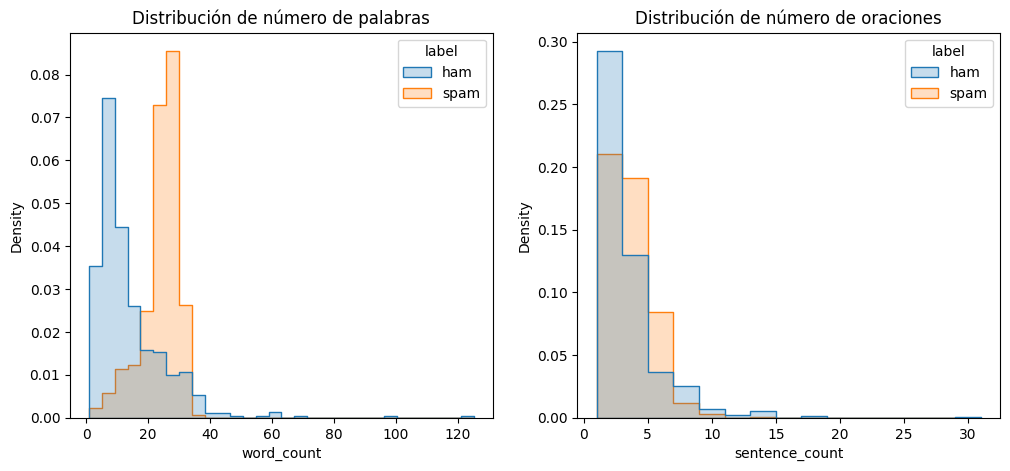

        word_count  sentence_count    label_num
count  1494.000000     1494.000000  1494.000000
mean     18.857430        2.962517     0.500000
std      10.169911        2.213927     0.500167
min       1.000000        1.000000     0.000000
25%      10.000000        1.000000     0.000000
50%      20.000000        2.000000     0.500000
75%      26.000000        4.000000     1.000000
max     125.000000       31.000000     1.000000


In [ ]:
# Crear columnas con número de palabras y número de oraciones
df_balanced['word_count'] = df_balanced['message'].apply(lambda x: len(str(x).split()))
df_balanced['sentence_count'] = df_balanced['message'].apply(lambda x: len(str(x).split('.')))

# Visualizar histogramas
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_balanced, x='word_count', hue='label', bins=30, element='step', stat='density', common_norm=False)
plt.title('Distribución de número de palabras')
plt.subplot(1,2,2)
sns.histplot(df_balanced, x='sentence_count', hue='label', bins=15, element='step', stat='density', common_norm=False)
plt.title('Distribución de número de oraciones')
plt.show()

# Estadísticas descriptivas
print(df_balanced[['word_count', 'sentence_count', 'label_num']].describe())


In [ ]:
display(df_balanced.head())

,label,message,label_num,word_count,sentence_count,clean_message
3714,ham,"I am late,so call you tomorrow morning.take ca...",0,12,13,lateso call tomorrow morningtake care sweet dr...
1311,ham,U r too much close to my heart. If u go away i...,0,20,4,u r much close heart u go away shattered plz stay
548,ham,Wait &lt;#&gt; min..,0,3,3,wait ltgt min
1324,ham,Can you call me plz. Your number shows out of ...,0,29,3,call plz number show coveragd area urgnt call ...
3184,ham,MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOU...,0,13,2,maybe woke fucking 3 wouldnt problem


Diagrama de correlación


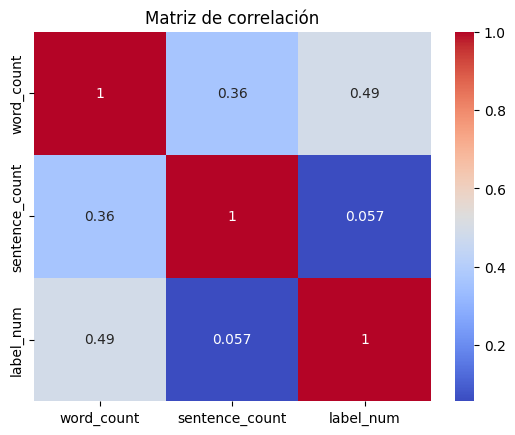

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_balanced[['word_count', 'sentence_count', 'label_num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()


procesamiento del texto

In [ ]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df_balanced['clean_message'] = df_balanced['message'].apply(preprocess_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Modelo SVM con kernels lineal y RBF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, precision_score

# Vectorización TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X = tfidf_vectorizer.fit_transform(df_balanced['clean_message'])
y = df_balanced['label_num']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

# Predicción y evaluación
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

def evaluar_modelo(y_true, y_pred, nombre):
    print(f'Resultados para {nombre}')
    print('Matriz de confusión:')
    print(confusion_matrix(y_true, y_pred))
    print('Reporte clasificación:')
    print(classification_report(y_true, y_pred))
    print(f'Precisión: {precision_score(y_true, y_pred):.4f}')
    print('-'*40)

evaluar_modelo(y_test, y_pred_linear, 'SVM Kernel Lineal')
evaluar_modelo(y_test, y_pred_rbf, 'SVM Kernel RBF')


Resultados para SVM Kernel Lineal
Matriz de confusión:
[[144   1]
 [ 17 137]]
Reporte clasificación:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       145
           1       0.99      0.89      0.94       154

    accuracy                           0.94       299
   macro avg       0.94      0.94      0.94       299
weighted avg       0.95      0.94      0.94       299

Precisión: 0.9928
----------------------------------------
Resultados para SVM Kernel RBF
Matriz de confusión:
[[145   0]
 [ 19 135]]
Reporte clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       145
           1       1.00      0.88      0.93       154

    accuracy                           0.94       299
   macro avg       0.94      0.94      0.94       299
weighted avg       0.94      0.94      0.94       299

Precisión: 1.0000
----------------------------------------


VN = 144 (clase 0 bien clasificados)

FP = 1 (clase 0 predicho como 1)

FN = 17 (clase 1 predicho como 0)

VP = 137 (clase 1 bien clasificados)

### Histograma de errores

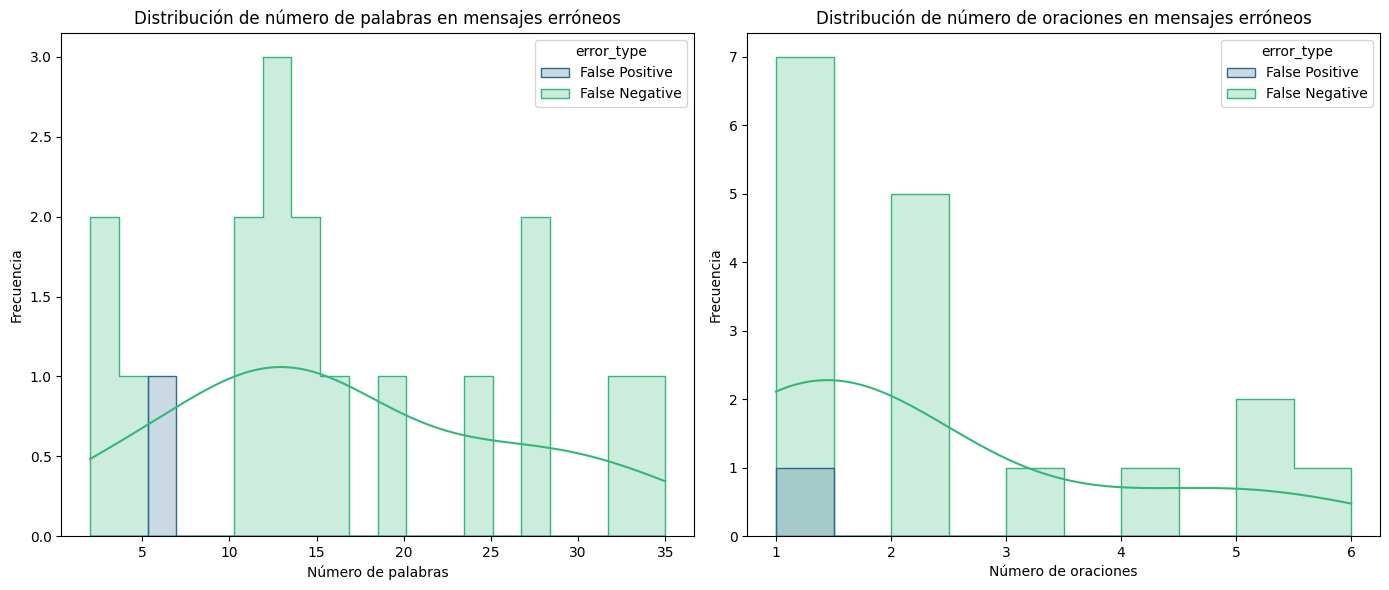

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener los índices de los mensajes de prueba
test_indices = y_test.index

# Crear un DataFrame con las predicciones, los valores reales y las características de los mensajes
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted_linear': y_pred_linear,
    'word_count': df_balanced.loc[test_indices, 'word_count'],
    'sentence_count': df_balanced.loc[test_indices, 'sentence_count'],
    'label': df_balanced.loc[test_indices, 'label']
})

# Identificar errores y crear una copia explícita
errors_df = results_df[results_df['actual'] != results_df['predicted_linear']].copy()

# Clasificar errores como Falsos Positivos (FP) o Falsos Negativos (FN)
# FP: actual = 0 (ham), predicted = 1 (spam)
# FN: actual = 1 (spam), predicted = 0 (ham)
errors_df['error_type'] = errors_df.apply(lambda row:
                                          'False Positive' if row['actual'] == 0 else 'False Negative',
                                          axis=1)

plt.figure(figsize=(14, 6))

# Histograma de word_count para errores
plt.subplot(1, 2, 1)
sns.histplot(data=errors_df, x='word_count', hue='error_type', bins=20, kde=True, palette='viridis', element='step')
plt.title('Distribución de número de palabras en mensajes erróneos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

# Histograma de sentence_count para errores
plt.subplot(1, 2, 2)
sns.histplot(data=errors_df, x='sentence_count', hue='error_type', bins=10, kde=True, palette='viridis', element='step')
plt.title('Distribución de número de oraciones en mensajes erróneos')
plt.xlabel('Número de oraciones')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Matriz de Confusión del modelo SVM Kernel Lineal

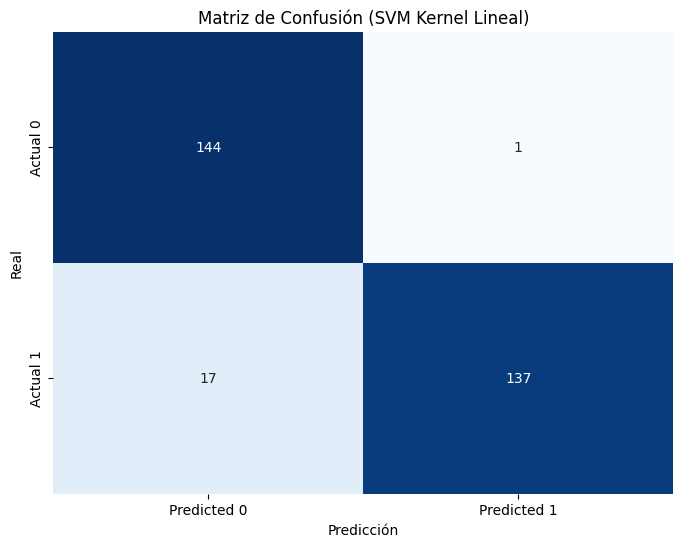

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión para el modelo SVM Kernel Lineal
cm_linear = confusion_matrix(y_test, y_pred_linear)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión (SVM Kernel Lineal)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Matriz de Confusión del modelo SVM Kernel RBF

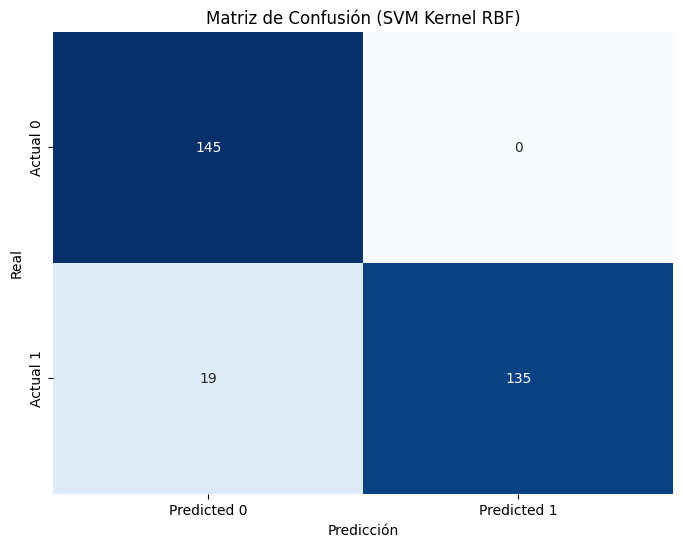

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión para el modelo SVM Kernel RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión (SVM Kernel RBF)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Diagrama de ROC

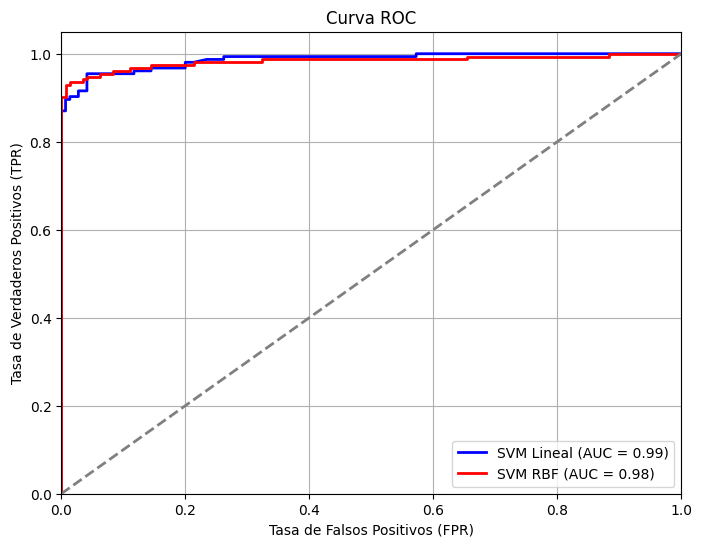

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Assuming df_balanced and clean_message are available from previous cells.
# Re-vectorize and split data to ensure X_test and y_test are in scope
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X = tfidf_vectorizer.fit_transform(df_balanced['clean_message'])
y = df_balanced['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-train models to ensure svm_linear and svm_rbf are in scope
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

# Obtener las probabilidades de predicción para la clase positiva (spam)
# Para SVC, se usa `decision_function` para obtener los scores de decisión.
y_score_linear = svm_linear.decision_function(X_test)
y_score_rbf = svm_rbf.decision_function(X_test)

# Calcular la curva ROC y el área bajo la curva (AUC)

# Para SVM lineal
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_score_linear)
roc_auc_linear = auc(fpr_linear, tpr_linear)

# Para SVM RBF
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_score_rbf)
roc_auc_rbf = auc(fpr_rbf, tpr_rbf)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='blue', lw=2, label=f'SVM Lineal (AUC = {roc_auc_linear:.2f})')
plt.plot(fpr_rbf, tpr_rbf, color='red', lw=2, label=f'SVM RBF (AUC = {roc_auc_rbf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()